# Task 3: Sound Data Collection and Processing

**Goal:** load each group member's 2 submitted voice samples ("Yes, approve" / "Confirm transaction"), display them as waveforms and spectrograms, apply augmentations, and extract features into `audio_features.csv` for the later Voiceprint Verification Model.

**Group members / files** (in `../audio_data/`):

| Member | approve | confirm |
|---|---|---|
| M1 | M1_approve.mp4 | M1_confirm.mp4 |
| M2 | M2_approve.mp4 | M2_confirm.mp4 |
| M3 | M3_approve.ogg | M3_confirm.ogg |
| M4 | M4_approve.ogg | M4_confirm.ogg |

**Format note:** the `.mp4` files are audio-only recordings (iPhone Voice Memos saved as `.mp4`/AAC). `soundfile`/`librosa` can't decode AAC directly, so we convert those to WAV on the fly using a bundled FFmpeg binary (`imageio-ffmpeg`, installed for this task alongside `librosa` and `soundfile`) before loading. The `.ogg` files load natively.

## 1. Load raw audio

In [2]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio_ffmpeg
import subprocess
import tempfile
import os

AUDIO_DIR = '../audio_data'
DATA_DIR = '../data/processed'
TARGET_SR = 22050

FFMPEG_EXE = imageio_ffmpeg.get_ffmpeg_exe()

# filename (without extension) -> (member, phrase)
AUDIO_META = {
    'M1_approve': ('M1', 'approve'),
    'M1_confirm': ('M1', 'confirm'),
    'M2_approve': ('M2', 'approve'),
    'M2_confirm': ('M2', 'confirm'),
    'M3_approve': ('M3', 'approve'),
    'M3_confirm': ('M3', 'confirm'),
    'M4_approve': ('M4', 'approve'),
    'M4_confirm': ('M4', 'confirm'),
}

FILE_EXT = {
    'M1_approve': '.mp4', 'M1_confirm': '.mp4',
    'M2_approve': '.mp4', 'M2_confirm': '.mp4',
    'M3_approve': '.ogg', 'M3_confirm': '.ogg',
    'M4_approve': '.ogg', 'M4_confirm': '.ogg',
}

def load_audio(path, target_sr=TARGET_SR):
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.mp4', '.m4a', '.mov'):
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tmp_path = tmp.name
        subprocess.run(
            [FFMPEG_EXE, '-y', '-i', path, '-ar', str(target_sr), '-ac', '1', tmp_path],
            capture_output=True, check=True,
        )
        y, sr = librosa.load(tmp_path, sr=target_sr)
        os.remove(tmp_path)
        return y, sr
    return librosa.load(path, sr=target_sr)

raw_audio = {}
for name, ext in FILE_EXT.items():
    path = os.path.join(AUDIO_DIR, f'{name}{ext}')
    y, sr = load_audio(path)
    raw_audio[name] = (y, sr)
    member, phrase = AUDIO_META[name]
    print(f'{name:12s} ({member}, {phrase:8s}) -> {len(y)/sr:.2f}s at {sr} Hz')


M1_approve   (M1, approve ) -> 2.24s at 22050 Hz
M1_confirm   (M1, confirm ) -> 3.18s at 22050 Hz
M2_approve   (M2, approve ) -> 2.52s at 22050 Hz
M2_confirm   (M2, confirm ) -> 2.99s at 22050 Hz
M3_approve   (M3, approve ) -> 2.24s at 22050 Hz
M3_confirm   (M3, confirm ) -> 2.12s at 22050 Hz
M4_approve   (M4, approve ) -> 3.03s at 22050 Hz
M4_confirm   (M4, confirm ) -> 2.73s at 22050 Hz


## 2. Waveforms and spectrograms

Displayed for every sample, labeled by member and phrase.

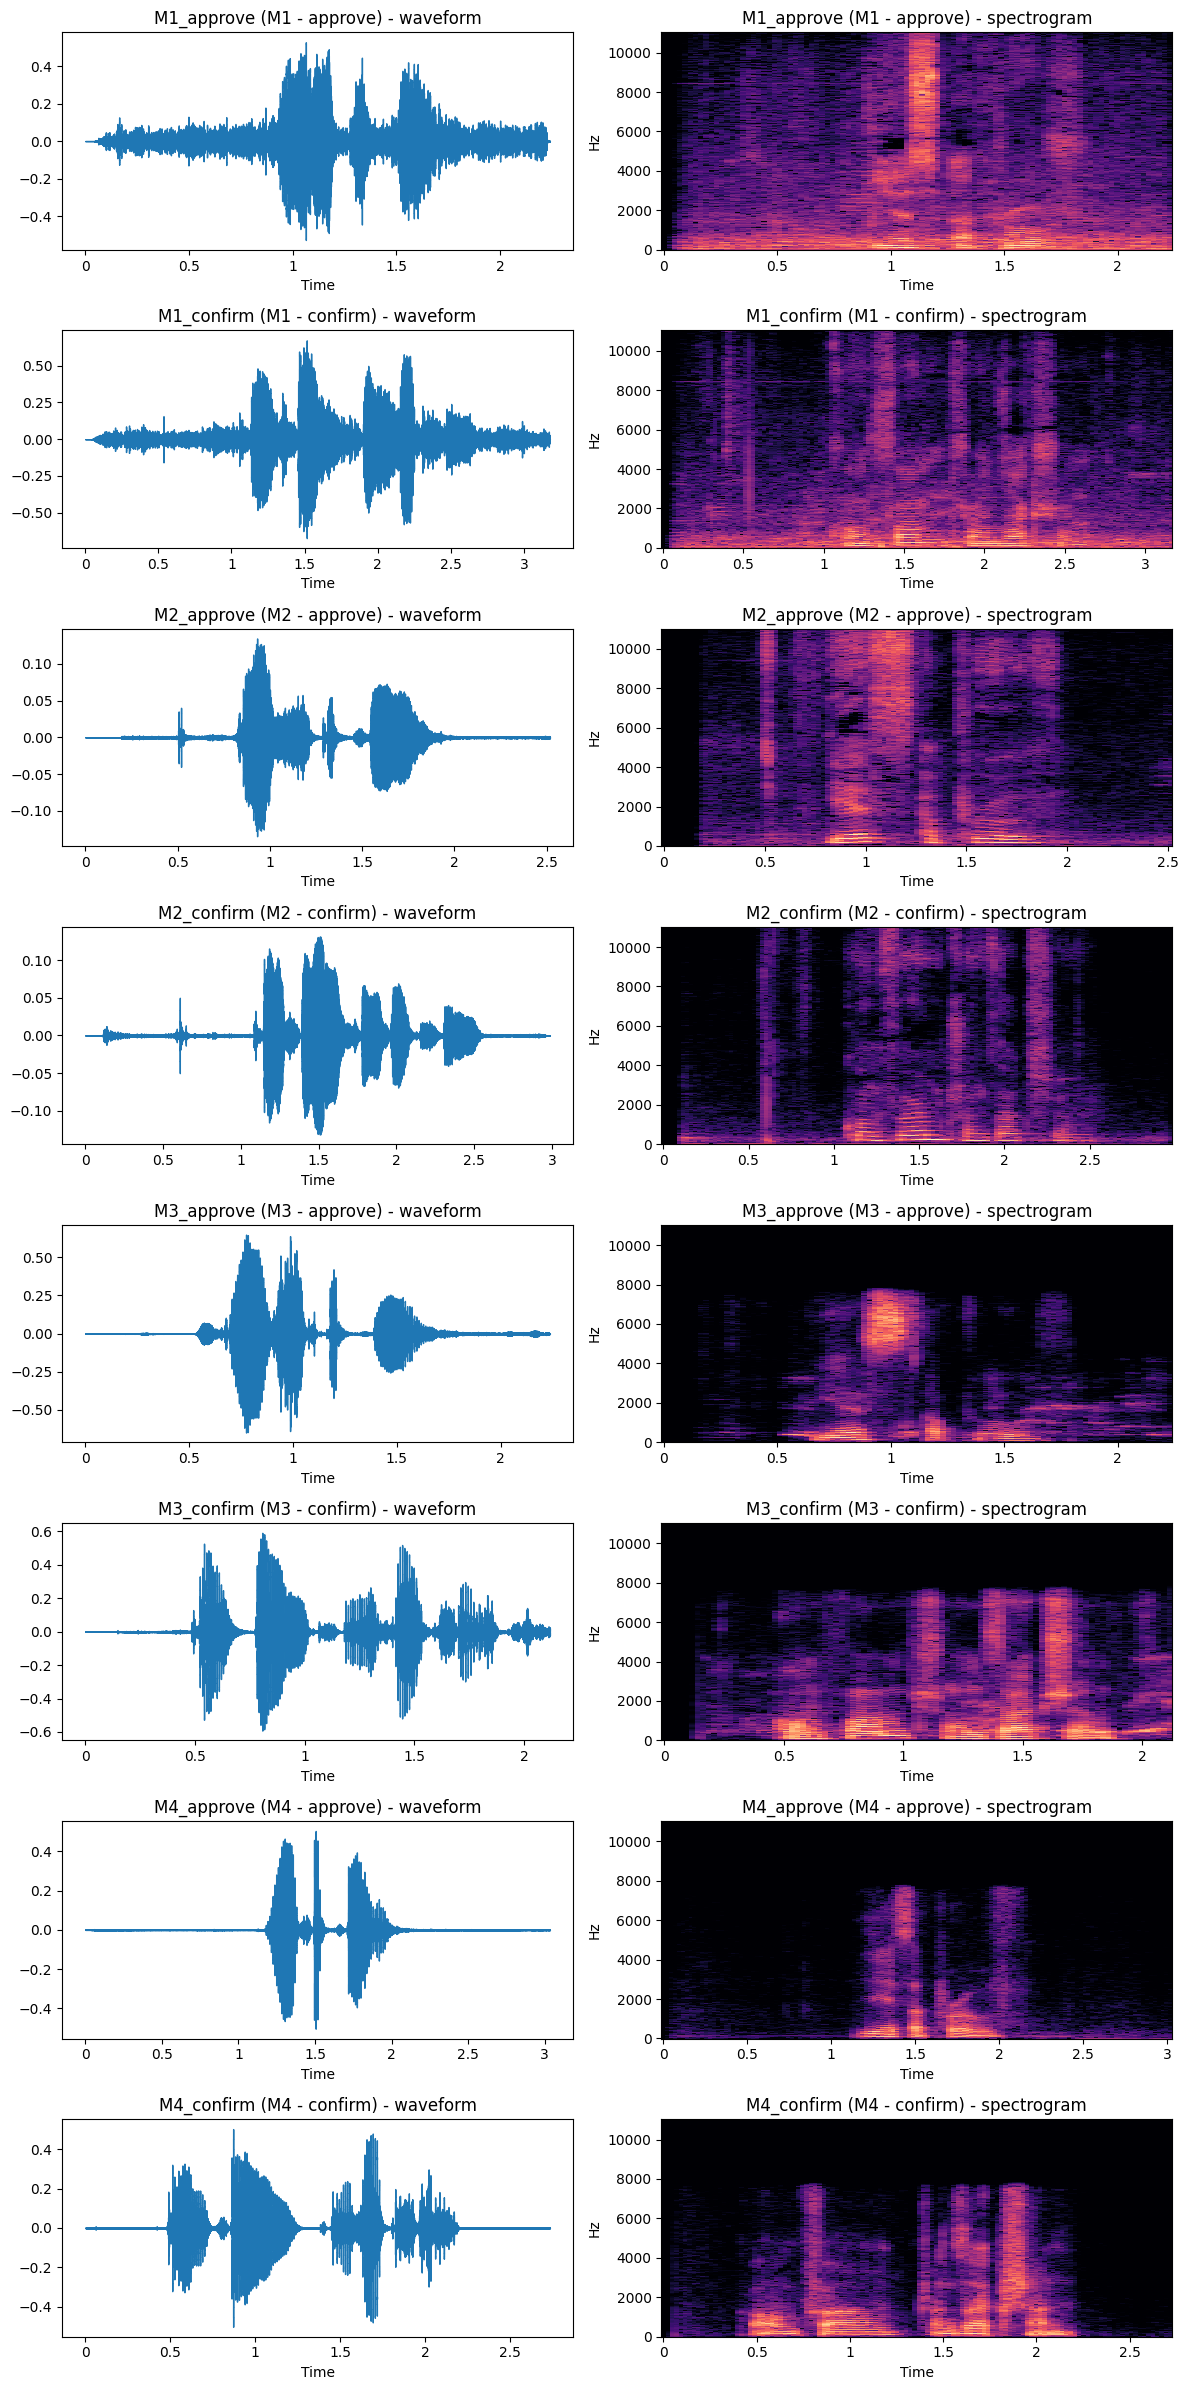

In [3]:
fig, axes = plt.subplots(len(raw_audio), 2, figsize=(12, 3 * len(raw_audio)))

for row, (name, (y, sr)) in enumerate(raw_audio.items()):
    member, phrase = AUDIO_META[name]

    librosa.display.waveshow(y, sr=sr, ax=axes[row, 0])
    axes[row, 0].set_title(f'{name} ({member} - {phrase}) - waveform')

    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz', ax=axes[row, 1])
    axes[row, 1].set_title(f'{name} ({member} - {phrase}) - spectrogram')

plt.tight_layout()
plt.show()


**Interpretation:**
- Durations are fairly consistent across members and phrases (2.12s-3.18s) - no outliers after the earlier fix to M4's originally much longer (4-6s) recordings (see Task 3 discussion).
- **M2's recordings stand out as noticeably quieter**: RMS energy is 0.0085-0.0125, roughly 3-8x lower than every other member's 0.02-0.068 range. This shows up visually as a flatter, lower-amplitude waveform for M2 compared to the others. Correspondingly, M2 also has the highest zero-crossing rate (0.199 for "approve") and spectral centroid (3380 Hz) of any sample - consistent with a quieter recording having a higher proportion of breath/background noise relative to voiced signal.
- Spectral centroid across all samples falls in the 1608-3380 Hz range, consistent with typical human speech (energy concentrated in the lower-mid frequency bands, visible in the spectrograms as the brightest region sitting below ~4 kHz with a fading tail above it).
- "Confirm" recordings tend to run longer than "approve" for the same member (e.g. M1: 3.18s vs 2.24s; M3 is the exception at 2.12s vs 2.24s), which tracks with "Confirm transaction" being a longer phrase than "Yes, approve".

## 3. Augmentations

We apply the three augmentations suggested by the assignment:
- **Pitch shift** (+4 semitones)
- **Time stretch** (1.2x speed)
- **Background noise** (added Gaussian noise)

Demonstrated first on one sample, then applied to all 8.

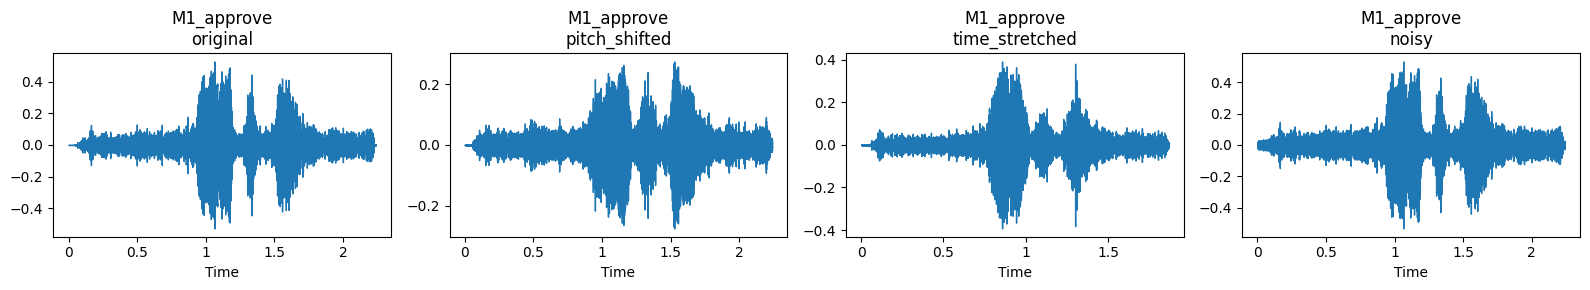

In [4]:
def augment_pitch_shift(y, sr, n_steps=4):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def augment_time_stretch(y, sr, rate=1.2):
    return librosa.effects.time_stretch(y=y, rate=rate)

# Seeded RNG so the "noisy" augmentation is reproducible across notebook re-runs
# (np.random.randn without a fixed seed would produce different features every run).
_noise_rng = np.random.default_rng(42)

def augment_add_noise(y, sr, noise_factor=0.01):
    return y + noise_factor * _noise_rng.standard_normal(len(y))

AUGMENTATIONS = {
    'original': lambda y, sr: y,
    'pitch_shifted': augment_pitch_shift,
    'time_stretched': augment_time_stretch,
    'noisy': augment_add_noise,
}

demo_name = 'M1_approve'
demo_y, demo_sr = raw_audio[demo_name]
demo_versions = {aug_name: fn(demo_y, demo_sr) for aug_name, fn in AUGMENTATIONS.items()}

fig, axes = plt.subplots(1, len(demo_versions), figsize=(4 * len(demo_versions), 3))
for ax, (aug_name, y_aug) in zip(axes, demo_versions.items()):
    librosa.display.waveshow(y_aug, sr=demo_sr, ax=ax)
    ax.set_title(f'{demo_name}\n{aug_name}')
plt.tight_layout()
plt.show()


In [5]:
augmented_audio = {}
for name, (y, sr) in raw_audio.items():
    for aug_name, fn in AUGMENTATIONS.items():
        augmented_audio[f'{name}__{aug_name}'] = (fn(y, sr), sr)

print('Total samples after augmentation:', len(augmented_audio))


Total samples after augmentation: 32


## 4. Feature extraction

For each sample (original + augmented versions) we compute, pooled across time (mean and std, so variable-length clips all produce a fixed-length feature vector):
- **MFCCs** (13 coefficients) -> 26 features
- **Spectral roll-off** -> 2 features
- **RMS energy** -> 2 features
- **Zero-crossing rate** -> 2 features
- **Spectral centroid** -> 2 features
- **Duration** (seconds) -> 1 feature

Saved with metadata (`member`, `phrase`, `augmentation`, `source_file`) into `audio_features.csv`.

In [6]:
def extract_features(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    features = {}
    for i in range(mfcc.shape[0]):
        features[f'mfcc_{i}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i}_std'] = float(np.std(mfcc[i]))
    features['rolloff_mean'] = float(np.mean(rolloff))
    features['rolloff_std'] = float(np.std(rolloff))
    features['rms_mean'] = float(np.mean(rms))
    features['rms_std'] = float(np.std(rms))
    features['zcr_mean'] = float(np.mean(zcr))
    features['zcr_std'] = float(np.std(zcr))
    features['centroid_mean'] = float(np.mean(centroid))
    features['centroid_std'] = float(np.std(centroid))
    features['duration'] = float(len(y) / sr)
    return features

rows = []
for key, (y, sr) in augmented_audio.items():
    name, aug_name = key.split('__')
    member, phrase = AUDIO_META[name]
    feats = extract_features(y, sr)
    row = {'source_file': name, 'member': member, 'phrase': phrase, 'augmentation': aug_name}
    row.update(feats)
    rows.append(row)

audio_features = pd.DataFrame(rows)
print('audio_features shape:', audio_features.shape)
audio_features.head()


audio_features shape: (32, 39)


,source_file,member,phrase,augmentation,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,...,mfcc_12_std,rolloff_mean,rolloff_std,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,duration
0,M1_approve,M1,approve,original,-221.897476,83.670998,116.272621,40.421513,24.998985,18.403837,...,8.380674,3921.373882,1881.118977,0.060558,0.046284,0.081306,0.095942,1931.063308,1268.087842,2.240000
1,M1_approve,M1,approve,pitch_shifted,-245.787415,79.079506,116.285309,35.316845,22.496164,19.381111,...,7.808803,4295.652032,2066.747504,0.037895,0.024766,0.096655,0.103844,2034.696853,1196.644387,2.240000
2,M1_approve,M1,approve,time_stretched,-254.648026,81.895935,113.902908,40.617832,26.927996,19.152967,...,9.044896,4023.120117,1891.452179,0.041544,0.032772,0.092382,0.118287,1956.807353,1270.262753,1.866667
3,M1_approve,M1,approve,noisy,-160.331544,37.419077,68.656900,28.821920,37.719572,13.430084,...,6.843185,7483.565057,1422.077623,0.061842,0.045537,0.160166,0.098976,3362.425342,1056.003122,2.240000
4,M1_confirm,M1,confirm,original,-221.452774,75.125328,125.715469,36.696461,13.819286,19.402349,...,8.654077,3592.351270,1863.325570,0.068070,0.055793,0.068994,0.043547,1699.443773,802.891742,3.178685


## 5. Save extracted features

In [7]:
out_path = os.path.join(DATA_DIR, 'audio_features.csv')
audio_features.to_csv(out_path, index=False)
print('Saved', out_path, 'with shape', audio_features.shape)
audio_features[['source_file', 'member', 'phrase', 'augmentation', 'duration', 'rms_mean', 'centroid_mean']].head(12)


Saved ../data/processed\audio_features.csv with shape (32, 39)


,source_file,member,phrase,augmentation,duration,rms_mean,centroid_mean
0,M1_approve,M1,approve,original,2.240000,0.060558,1931.063308
1,M1_approve,M1,approve,pitch_shifted,2.240000,0.037895,2034.696853
2,M1_approve,M1,approve,time_stretched,1.866667,0.041544,1956.807353
3,M1_approve,M1,approve,noisy,2.240000,0.061842,3362.425342
4,M1_confirm,M1,confirm,original,3.178685,0.068070,1699.443773
5,M1_confirm,M1,confirm,pitch_shifted,3.178685,0.046362,1813.641189
6,M1_confirm,M1,confirm,time_stretched,2.648889,0.043347,1715.622644
7,M1_confirm,M1,confirm,noisy,3.178685,0.069398,3155.640358
8,M2_approve,M2,approve,original,2.517370,0.008525,3379.744336
9,M2_approve,M2,approve,pitch_shifted,2.517370,0.004918,3130.450273
